In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import zscore

In [2]:
# Load dataset
df = pd.read_csv('BrentOilPrices.csv')
df.head()

,Date,Price
0,20-May-87,18.63
1,21-May-87,18.45
2,22-May-87,18.55
3,25-May-87,18.60
4,26-May-87,18.63


In [ ]:
# Rename columns
df = df.rename(columns={'Date': 'date',
                        'Price': 'price'
})

In [4]:
df.tail()

,date,price
9006,"Nov 08, 2022",96.85
9007,"Nov 09, 2022",93.05
9008,"Nov 10, 2022",94.25
9009,"Nov 11, 2022",96.37
9010,"Nov 14, 2022",93.59


In [5]:
df.shape

(9011, 2)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9011 entries, 0 to 9010
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    9011 non-null   object 
 1   price   9011 non-null   float64
dtypes: float64(1), object(1)
memory usage: 140.9+ KB


In [7]:
# Convert the 'Date' column to datetime format
df['date'] = pd.to_datetime(df['date'])

In [8]:
# Sort the dataset by date to maintain chronological order
df.sort_index(inplace=True)

In [9]:
df.dtypes

date     datetime64[ns]
price           float64
dtype: object

In [10]:
# Set 'date' as the index for time series analysis
df.set_index('date', inplace=True)

In [11]:
df.head()

,price
date,
1987-05-20,18.63
1987-05-21,18.45
1987-05-22,18.55
1987-05-25,18.60
1987-05-26,18.63


In [12]:
df.isnull().sum()

price    0
dtype: int64

In [13]:
df.index.duplicated().sum()

np.int64(0)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9011 entries, 1987-05-20 to 2022-11-14
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   9011 non-null   float64
dtypes: float64(1)
memory usage: 398.8 KB


In [15]:
df['zscore'] = zscore(df['price'])

In [16]:
df.head()

,price,zscore
date,,
1987-05-20,18.63,-0.906644
1987-05-21,18.45,-0.912122
1987-05-22,18.55,-0.909079
1987-05-25,18.60,-0.907557
1987-05-26,18.63,-0.906644


In [17]:
# Filter rows where z-score < -3
outliers_negative = df[df['zscore'] < -3]
print(outliers_negative.shape)

(0, 2)


In [18]:
# Filter rows where z-score > 3
outliers_positive = df[df['zscore'] > 3]
print(outliers_positive.shape)

(0, 2)


In [19]:
# Remove outliers beyond ±3
df = df[df['zscore'].abs() < 3]

In [20]:
df.shape

(9011, 2)

In [21]:
df.head(3)

,price,zscore
date,,
1987-05-20,18.63,-0.906644
1987-05-21,18.45,-0.912122
1987-05-22,18.55,-0.909079


In [22]:
df.drop(columns='zscore', inplace=True)

In [23]:
df.head(3)

,price
date,
1987-05-20,18.63
1987-05-21,18.45
1987-05-22,18.55


In [24]:
df.shape

(9011, 1)

In [25]:
print(pd.infer_freq(df.index))

None


In [26]:
daily = pd.date_range(start=df.index.min(), end=df.index.max(), freq= 'D')
df= df.reindex(daily)
daily

DatetimeIndex(['1987-05-20', '1987-05-21', '1987-05-22', '1987-05-23',
               '1987-05-24', '1987-05-25', '1987-05-26', '1987-05-27',
               '1987-05-28', '1987-05-29',
               ...
               '2022-11-05', '2022-11-06', '2022-11-07', '2022-11-08',
               '2022-11-09', '2022-11-10', '2022-11-11', '2022-11-12',
               '2022-11-13', '2022-11-14'],
              dtype='datetime64[ns]', length=12963, freq='D')

In [27]:
df.isnull().sum()

price    3952
dtype: int64

In [28]:
df.shape

(12963, 1)

In [30]:
manually_sorted = df.loc[['1987-05-22', '1987-05-23', '1987-05-24', '1987-05-25']]
manually_sorted

,price
1987-05-22,18.55
1987-05-23,NaN
1987-05-24,NaN
1987-05-25,18.60


In [31]:
df.shape

(12963, 1)

In [32]:
df['price'] = df['price'].ffill()

In [33]:
df.isnull().sum()

price    0
dtype: int64

In [34]:
manually_sorted_after_ffill= df.loc[['1987-05-22', '1987-05-23', '1987-05-24', '1987-05-25']]
manually_sorted_after_ffill

,price
1987-05-22,18.55
1987-05-23,18.55
1987-05-24,18.55
1987-05-25,18.60


In [35]:
print(pd.infer_freq(df.index))

D


In [36]:
weekly_counts = df['price'].resample('W').sum().to_frame()
weekly_counts.index.name = 'date'
weekly_counts.head()

,price
date,
1987-05-24,92.73
1987-05-31,130.17
1987-06-07,130.81
1987-06-14,131.33
1987-06-21,132.91


In [37]:
# Month and day-level features
df['day_of_week'] = df.index.dayofweek + 1  # Monday=1, Sunday=7
df['month'] = df.index.month
df['day_name'] = df.index.day_name()    # Monday, Tuesday, etc.


In [38]:
df.index.name = 'date'
df.head(7)

,price,day_of_week,month,day_name
date,,,,
1987-05-20,18.63,3,5,Wednesday
1987-05-21,18.45,4,5,Thursday
1987-05-22,18.55,5,5,Friday
1987-05-23,18.55,6,5,Saturday
1987-05-24,18.55,7,5,Sunday
1987-05-25,18.60,1,5,Monday
1987-05-26,18.63,2,5,Tuesday


Since day_of_week column is represented numerically, the day_name column was created to identify the corresponding weekday names for better understanding.

In [39]:
# Remove day_name column
df.drop(columns= ['day_name'], inplace= True)

In [40]:
df.head()

,price,day_of_week,month
date,,,
1987-05-20,18.63,3,5
1987-05-21,18.45,4,5
1987-05-22,18.55,5,5
1987-05-23,18.55,6,5
1987-05-24,18.55,7,5


In [41]:
ffill_with_added_features= df.loc[['1987-05-22', '1987-05-23', '1987-05-24', '1987-05-25']]
ffill_with_added_features

,price,day_of_week,month
date,,,
1987-05-22,18.55,5,5
1987-05-23,18.55,6,5
1987-05-24,18.55,7,5
1987-05-25,18.60,1,5


In [42]:
df.isnull().sum()

price          0
day_of_week    0
month          0
dtype: int64

In [43]:
df.shape

(12963, 3)

In [44]:
df_monthly = df['price'].resample('MS').sum()

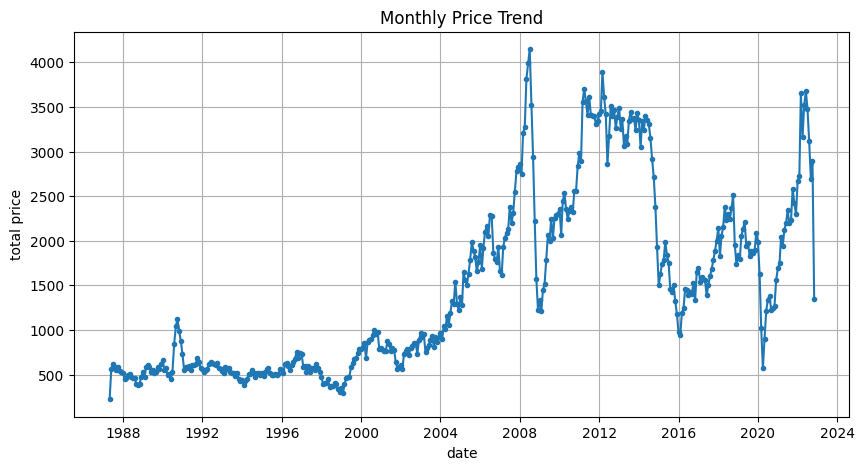

In [45]:
plt.figure(figsize=(10, 5))
plt.plot(df_monthly, marker= '.')
plt.title('Monthly Price Trend')
plt.xlabel('date')
plt.ylabel('total price')
plt.grid(True)
plt.show()

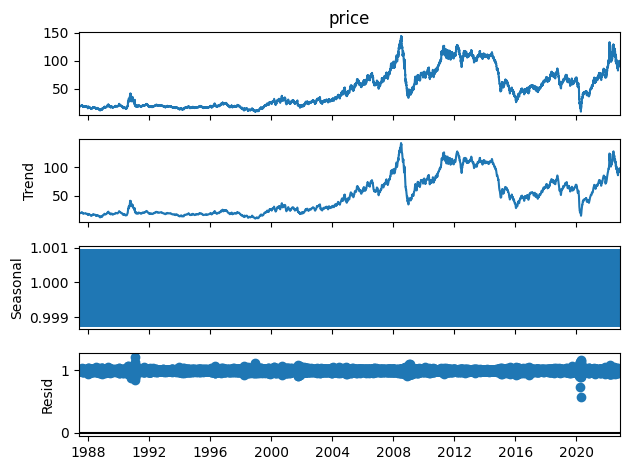

In [46]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Multiplicative decomposition (for seasonal data)
decomposition = seasonal_decompose(df['price'], model='multiplicative')

# Plot decomposition
decomposition.plot()
plt.tight_layout()
plt.show()

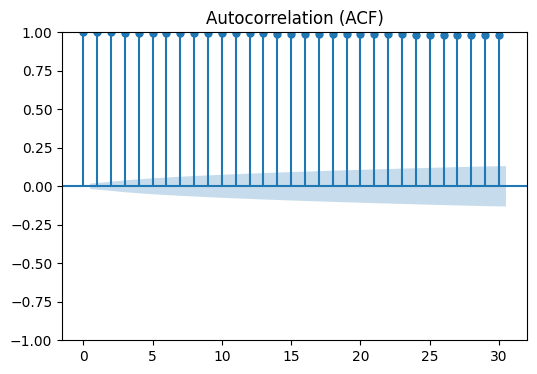

In [47]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(figsize=(6, 4))
plot_acf(df['price'], lags=30, ax=ax)
plt.title('Autocorrelation (ACF)')
plt.show()

Since the ACF shows a slow decay with no clear cutoff, the series in non-stationary. Therefore, MA order (q) cannot be determined from this plot. Differencing is required before identifying q.

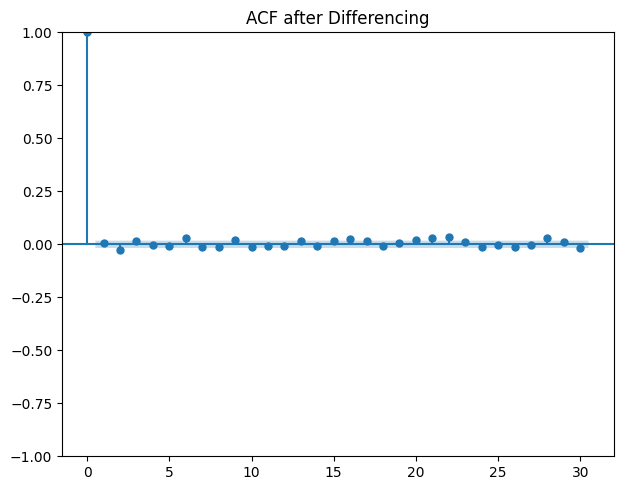

In [48]:
# First-order differencing
df['price_diff'] = df['price'].diff()

# Plot ACF for best transformed series
series = df['price_diff'].dropna()
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plot_acf(series, lags=30, ax=plt.gca())
plt.title('ACF after Differencing')

plt.tight_layout()
plt.show()

After first-order differencing, the ACF plot showed no significant spikes beyond lag 0, indicating the absence of a moving average component. Therefore, the MA order (q) was selected as 0.

In [49]:
df.drop(columns= ['price_diff'], inplace= True)

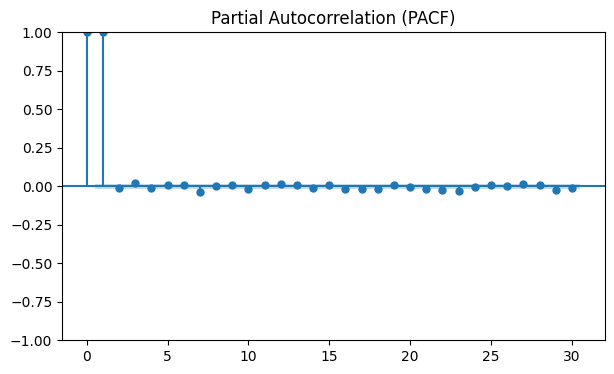

In [50]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_pacf(df['price'], lags=30, ax=ax)
plt.title('Partial Autocorrelation (PACF)')
plt.show()

The PACF plot showed a significant spike at lag 1 and sharp cutoff afterward, indicating an autoregressive component of order 1. Therefore, p was selected as 1.

In [51]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['price'])

print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:')
for key, value in result[4].items():
    print(f'   {key}: {value}')

ADF Statistic: -1.9488216105940637
p-value: 0.309453625079366
Critical Values:
   1%: -3.4308561991797255
   5%: -2.8617637154959716
   10%: -2.566889078817277


The Augmented Dickey-Fuller (ADF) test resulted in a p-value of 0.309, indicating that the original series is non-stationary. Therefore, first-order differencing (d = 1) was applied to achieve stationarity, and no further differencing was required.

RMSE: 14.39
MAE : 12.76
MAPE: 12.91%


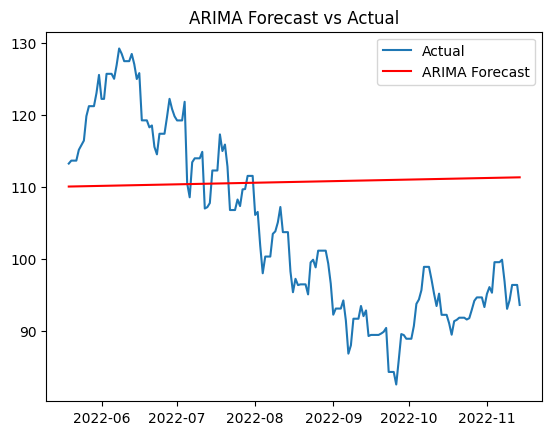

In [52]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Train-test split
train = df.iloc[:-180]
test = df.iloc[-180:]

# Fit ARIMA Model
model_arima = ARIMA(train['price'], order=(1, 1, 0), trend='t') # (p, d, q)
model_arima_fit = model_arima.fit()

# print(model_arima_fit.summary())

# Forecast
forecast_arima = model_arima_fit.forecast(steps=len(test))

# Evaluation
rmse= np.sqrt(mean_squared_error(test['price'], forecast_arima))
mae= mean_absolute_error(test['price'], forecast_arima)
mape = np.mean(np.abs((test['price'] - forecast_arima) / test['price'])) * 100

print(f'RMSE: {rmse:.2f}')
print(f'MAE : {mae:.2f}')
print(f'MAPE: {mape:.2f}%')

# Plot
plt.plot(test.index, test['price'], label= 'Actual')
plt.plot(test.index, forecast_arima, label='ARIMA Forecast', color='red')

plt.legend()
plt.title('ARIMA Forecast vs Actual')
plt.show()

In [53]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

# Data
series = df['price']

# Time Series Split
tscv = TimeSeriesSplit(n_splits=5)

# Store Results
rmse_scores_arima = []
mae_scores_arima = []
mape_scores_arima = []

# Cross Validation Loop
fold = 1

for train_index, test_index in tscv.split(series):

    # Split data
    train_cv = series.iloc[train_index]
    test_cv = series.iloc[test_index]

    # Fit Model
    model_cv = ARIMA(
        train_cv,
        order=(1,1,0),
        trend= 't'
    )

    fit_cv = model_cv.fit()

    # Forecast
    forecast_cv = fit_cv.forecast(
        steps=len(test_cv)
    )

    # Metrics
    rmse_arima_cv = np.sqrt(
        mean_squared_error(
            test_cv,
            forecast_cv
        )
    )

    mae_arima_cv = mean_absolute_error(
        test_cv,
        forecast_cv
    )

    mape_arima_cv = np.mean(
        np.abs(
            (test_cv - forecast_cv) / test_cv
        )
    ) * 100

    # Store metrics
    rmse_scores_arima.append(rmse_arima_cv)
    mae_scores_arima.append(mae_arima_cv)
    mape_scores_arima.append(mape_arima_cv)

    # Print fold results
    print(f"\nFold {fold}")
    print(f"RMSE: {rmse_arima_cv:.2f}")
    print(f"MAE : {mae_arima_cv:.2f}")
    print(f"MAPE: {mape_arima_cv:.2f}%")

    fold += 1

# Average Performance
print("\nAverage Cross-Validation Results")

print(f"Average RMSE: {np.mean(rmse_scores_arima):.2f}")
print(f"Average MAE : {np.mean(mae_scores_arima):.2f}")
print(f"Average MAPE: {np.mean(mape_scores_arima):.2f}%")


Fold 1
RMSE: 3.60
MAE : 2.82
MAPE: 19.56%

Fold 2
RMSE: 18.06
MAE : 16.35
MAPE: 54.91%

Fold 3
RMSE: 29.61
MAE : 23.63
MAPE: 29.20%

Fold 4
RMSE: 40.22
MAE : 28.47
MAPE: 55.37%

Fold 5
RMSE: 22.72
MAE : 17.17
MAPE: 26.35%

Average Cross-Validation Results
Average RMSE: 22.84
Average MAE : 17.69
Average MAPE: 37.08%


RMSE: 14.43
MAE : 12.78
MAPE: 12.94%


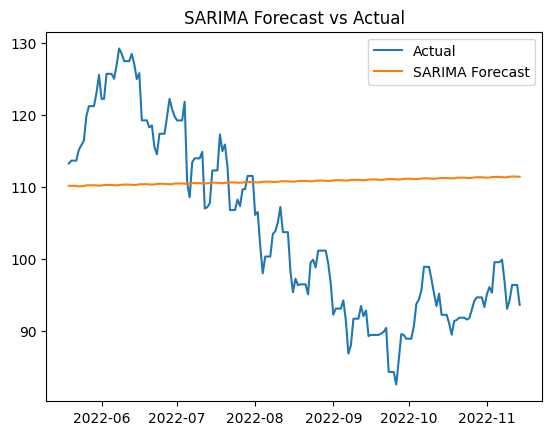

In [54]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Fit SARIMA model
model_sarima = SARIMAX(train['price'], order=(2,1,1), seasonal_order=(1,1,1,7)) # (p,d,q)  (P,D,Q,s)
model_sarima_fit = model_sarima.fit()

# Forecast
forecast_sarima = model_sarima_fit.forecast(steps=len(test))

# Evaluation
rmse= np.sqrt(mean_squared_error(test['price'], forecast_sarima))
mae= mean_absolute_error(test['price'], forecast_sarima)
mape = np.mean(np.abs((test['price'] - forecast_sarima) / test['price'])) * 100

print(f'RMSE: {rmse:.2f}')
print(f'MAE : {mae:.2f}')
print(f'MAPE: {mape:.2f}%')

# Plot
plt.plot(test.index, test['price'], label='Actual')
plt.plot(test.index, forecast_sarima, label='SARIMA Forecast')
plt.legend()
plt.title('SARIMA Forecast vs Actual')
plt.show()

In [55]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Data
series_sarima = df['price']

# Time Series Cross Validation
tscv_sarima = TimeSeriesSplit(n_splits=5)

# Store Metrics
rmse_scores_sarima = []
mae_scores_sarima = []
mape_scores_sarima = []

# Cross-Validation Loop
fold_sarima = 1

for train_index_sarima, test_index_sarima in tscv_sarima.split(series_sarima):

    # Train-Test Split
    train_sarima_cv = series_sarima.iloc[train_index_sarima]
    test_sarima_cv = series_sarima.iloc[test_index_sarima]

    # Fit SARIMA Model
    model_sarima_cv = SARIMAX(
        train_sarima_cv,

        # Non-seasonal order
        order=(2,1,1),

        # Seasonal order
        seasonal_order=(1,1,1,7)
    )

    fit_sarima_cv = model_sarima_cv.fit()

    # Forecast
    forecast_sarima_cv = fit_sarima_cv.forecast(
        steps=len(test_sarima_cv)
    )

    # Evaluation Metrics
    rmse_sarima_cv = np.sqrt(mean_squared_error(test_sarima_cv, forecast_sarima_cv))

    mae_sarima_cv = mean_absolute_error(test_sarima_cv, forecast_sarima_cv)

    mape_sarima_cv = np.mean(np.abs((test_sarima_cv - forecast_sarima_cv) / test_sarima_cv)) * 100

    # Store Metrics
    rmse_scores_sarima.append(rmse_sarima_cv)
    mae_scores_sarima.append(mae_sarima_cv)
    mape_scores_sarima.append(mape_sarima_cv)

    # Print Fold Results
    print(f"\nFold {fold_sarima}")
    print(f"RMSE: {rmse_sarima_cv:.2f}")
    print(f"MAE : {mae_sarima_cv:.2f}")
    print(f"MAPE: {mape_sarima_cv:.2f}%")

    fold_sarima += 1

# Average Results
print("\nAverage Cross-Validation Results")
print(f"Average RMSE: "f"{np.mean(rmse_scores_sarima):.2f}")
print(f"Average MAE : "f"{np.mean(mae_scores_sarima):.2f}")
print(f"Average MAPE: "f"{np.mean(mape_scores_sarima):.2f}%")


Fold 1
RMSE: 3.62
MAE : 2.84
MAPE: 19.67%

Fold 2
RMSE: 18.13
MAE : 16.43
MAPE: 55.21%

Fold 3
RMSE: 29.70
MAE : 23.72
MAPE: 29.32%

Fold 4
RMSE: 55.20
MAE : 39.54
MAPE: 76.44%

Fold 5
RMSE: 28.14
MAE : 21.38
MAPE: 30.12%

Average Cross-Validation Results
Average RMSE: 26.96
Average MAE : 20.78
Average MAPE: 42.15%


20:57:48 - cmdstanpy - INFO - Chain [1] start processing
21:02:24 - cmdstanpy - INFO - Chain [1] done processing


RMSE : 15.80
MAE  : 13.73
MAPE : 14.04%


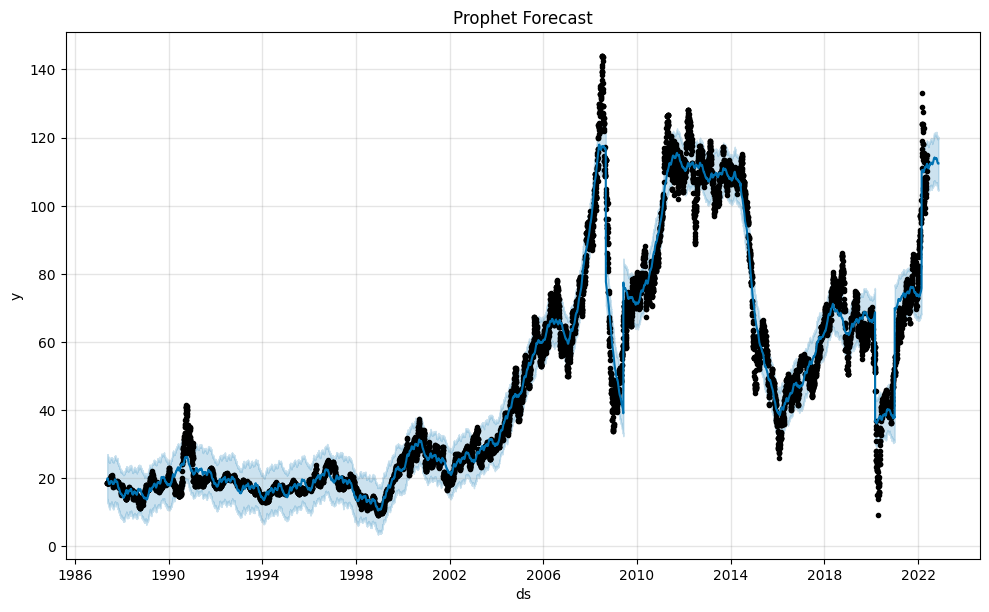

In [56]:
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Prepare data
df_prophet = df.reset_index().rename(columns={'date': 'ds', 'price': 'y'})


# Add Shock Regressors
# Financial Crisis (2008–2009)
df_prophet['financial_crisis'] = (
    (df_prophet['ds'] >= '2008-09-01') & 
    (df_prophet['ds'] <= '2009-06-01')
).astype(int)

# COVID (2020)
df_prophet['covid'] = (
    (df_prophet['ds'] >= '2020-03-01') & 
    (df_prophet['ds'] <= '2020-12-31')
).astype(int)

# Russia–Ukraine War (2022–present)
df_prophet['ukraine_war'] = (
    (df_prophet['ds'] >= '2022-02-24')
).astype(int)

# Oil Supply Shock (2014–2016 crash)
df_prophet['supply_shock'] = (
    (df_prophet['ds'] >= '2014-06-01') & 
    (df_prophet['ds'] <= '2016-02-01')
).astype(int)

# Train-test split
train_prophet = df_prophet.iloc[:-180]
test_prophet = df_prophet.iloc[-180:]

# Model
model_prophet = Prophet(
    seasonality_mode='additive',   # better for price data
    changepoint_prior_scale=0.08,
    n_changepoints=120,
    changepoint_range=0.9,
    seasonality_prior_scale = 0.5
)

# Add only useful seasonality
model_prophet.add_seasonality(name='yearly', period=365, fourier_order=10, prior_scale=5.0)
model_prophet.add_seasonality(name='monthly', period=30, fourier_order=5, prior_scale=5.0)
model_prophet.add_seasonality(name='weekly', period=7, fourier_order=6, prior_scale=5.0)

# Add regressors
model_prophet.add_regressor('financial_crisis')
model_prophet.add_regressor('covid')
model_prophet.add_regressor('ukraine_war')
model_prophet.add_regressor('supply_shock')

# Fit model
model_prophet.fit(train_prophet)

# Future dataframe (FIXED)
future = model_prophet.make_future_dataframe(periods=len(test_prophet), freq='D')

# Add regressors to future (CRITICAL)
future['financial_crisis'] = (
    (future['ds'] >= '2008-09-01') & 
    (future['ds'] <= '2009-06-01')
).astype(int)

future['covid'] = (
    (future['ds'] >= '2020-03-01') & 
    (future['ds'] <= '2020-12-31')
).astype(int)

future['ukraine_war'] = (
    (future['ds'] >= '2022-02-24')
).astype(int)

future['supply_shock'] = (
    (future['ds'] >= '2014-06-01') & 
    (future['ds'] <= '2016-02-01')
).astype(int)

# Forecast
forecast_prophet = model_prophet.predict(future)

# Evaluation
forecast_test = forecast_prophet[['ds', 'yhat']].iloc[-len(test_prophet):].reset_index(drop=True)
actual_test = test_prophet[['ds', 'y']].reset_index(drop=True)

rmse = np.sqrt(mean_squared_error(actual_test['y'], forecast_test['yhat']))
mae = mean_absolute_error(actual_test['y'], forecast_test['yhat'])
mape = np.mean(np.abs((actual_test['y'] - forecast_test['yhat']) /actual_test['y'])) * 100

print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"MAPE : {mape:.2f}%")

# Plot
model_prophet.plot(forecast_prophet)
plt.title('Prophet Forecast')
plt.show()

In [57]:
from prophet import Prophet
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np

# Prepare Prophet Data
df_prophet_cv = df.reset_index().rename(
    columns={
        'date': 'ds',
        'price': 'y'
    }
)

# Add Shock Regressors
# Financial Crisis
df_prophet_cv['financial_crisis'] = (
    (df_prophet_cv['ds'] >= '2008-09-01') &
    (df_prophet_cv['ds'] <= '2009-06-01')
).astype(int)

# COVID
df_prophet_cv['covid'] = (
    (df_prophet_cv['ds'] >= '2020-03-01') &
    (df_prophet_cv['ds'] <= '2020-12-31')
).astype(int)

# Ukraine War
df_prophet_cv['ukraine_war'] = (
    (df_prophet_cv['ds'] >= '2022-02-24')
).astype(int)

# Supply Shock
df_prophet_cv['supply_shock'] = (
    (df_prophet_cv['ds'] >= '2014-06-01') &
    (df_prophet_cv['ds'] <= '2016-02-01')
).astype(int)

# Time Series Cross Validation
tscv_prophet = TimeSeriesSplit(
    n_splits=5,
    test_size=180
)

# Store Metrics
rmse_scores_prophet = []
mae_scores_prophet = []
mape_scores_prophet = []

# Cross Validation Loop
fold_prophet = 1

for train_index_prophet, test_index_prophet in tscv_prophet.split(df_prophet_cv):

    # Train-Test Split
    train_prophet_cv = df_prophet_cv.iloc[train_index_prophet]

    test_prophet_cv = df_prophet_cv.iloc[test_index_prophet]

    # Prophet Model
    model_prophet_cv = Prophet(

        # Trend flexibility
        changepoint_prior_scale=0.005,

        # More changepoints
        n_changepoints=40,

        # Trend adaptability
        changepoint_range=0.95,

        # Better for price data
        seasonality_mode='additive',

        # Regularization
        seasonality_prior_scale=0.1,
    )

    # Add Seasonalities
    model_prophet_cv.add_seasonality(name='yearly', period=365, fourier_order=10, prior_scale=5.0)
    model_prophet_cv.add_seasonality(name='monthly', period=30, fourier_order=5, prior_scale=5.0)
    model_prophet_cv.add_seasonality(name='weekly', period=7, fourier_order=6, prior_scale=5.0)

    # Add Regressors
    model_prophet_cv.add_regressor('financial_crisis')

    model_prophet_cv.add_regressor('covid')

    model_prophet_cv.add_regressor('ukraine_war')

    model_prophet_cv.add_regressor('supply_shock')

    # Fit Model
    model_prophet_cv.fit(train_prophet_cv)

    # Predict on Test Set
    forecast_prophet_cv = model_prophet_cv.predict(test_prophet_cv)

    # Convert to NumPy Arrays
    y_true_prophet = test_prophet_cv['y'].values
    y_pred_prophet = forecast_prophet_cv['yhat'].values

    # Evaluation Metrics
    # RMSE
    rmse_prophet_cv = np.sqrt(mean_squared_error(y_true_prophet, y_pred_prophet))

    # MAE
    mae_prophet_cv = mean_absolute_error(y_true_prophet, y_pred_prophet)

    # MAPE
    mape_prophet_cv = np.mean(np.abs((y_true_prophet - y_pred_prophet) / y_true_prophet)) * 100

    # Store Metrics
    rmse_scores_prophet.append(rmse_prophet_cv)
    mae_scores_prophet.append(mae_prophet_cv)
    mape_scores_prophet.append(mape_prophet_cv)

    # Print Fold Results
    print(f"\nFold {fold_prophet}")

    print(f"RMSE: {rmse_prophet_cv:.2f}")

    print(f"MAE : {mae_prophet_cv:.2f}")

    print(f"MAPE: {mape_prophet_cv:.2f}%")

    fold_prophet += 1

# Average Cross Validation Results
print("\nAverage Cross-Validation Results")
print(f"Average RMSE: "f"{np.mean(rmse_scores_prophet):.2f}")
print(f"Average MAE : "f"{np.mean(mae_scores_prophet):.2f}")
print(f"Average MAPE: "f"{np.mean(mape_scores_prophet):.2f}%")

21:02:38 - cmdstanpy - INFO - Chain [1] start processing
21:03:00 - cmdstanpy - INFO - Chain [1] done processing



Fold 1
RMSE: 13.79
MAE : 13.56
MAPE: 32.30%


21:03:12 - cmdstanpy - INFO - Chain [1] start processing
21:03:37 - cmdstanpy - INFO - Chain [1] done processing



Fold 2
RMSE: 8.03
MAE : 5.99
MAPE: 11.17%


21:03:42 - cmdstanpy - INFO - Chain [1] start processing
21:03:57 - cmdstanpy - INFO - Chain [1] done processing



Fold 3
RMSE: 8.69
MAE : 7.08
MAPE: 8.94%


21:04:01 - cmdstanpy - INFO - Chain [1] start processing
21:04:13 - cmdstanpy - INFO - Chain [1] done processing



Fold 4
RMSE: 29.69
MAE : 25.64
MAPE: 24.67%


21:04:19 - cmdstanpy - INFO - Chain [1] start processing
21:04:39 - cmdstanpy - INFO - Chain [1] done processing



Fold 5
RMSE: 15.98
MAE : 13.86
MAPE: 14.21%

Average Cross-Validation Results
Average RMSE: 15.24
Average MAE : 13.23
Average MAPE: 18.26%


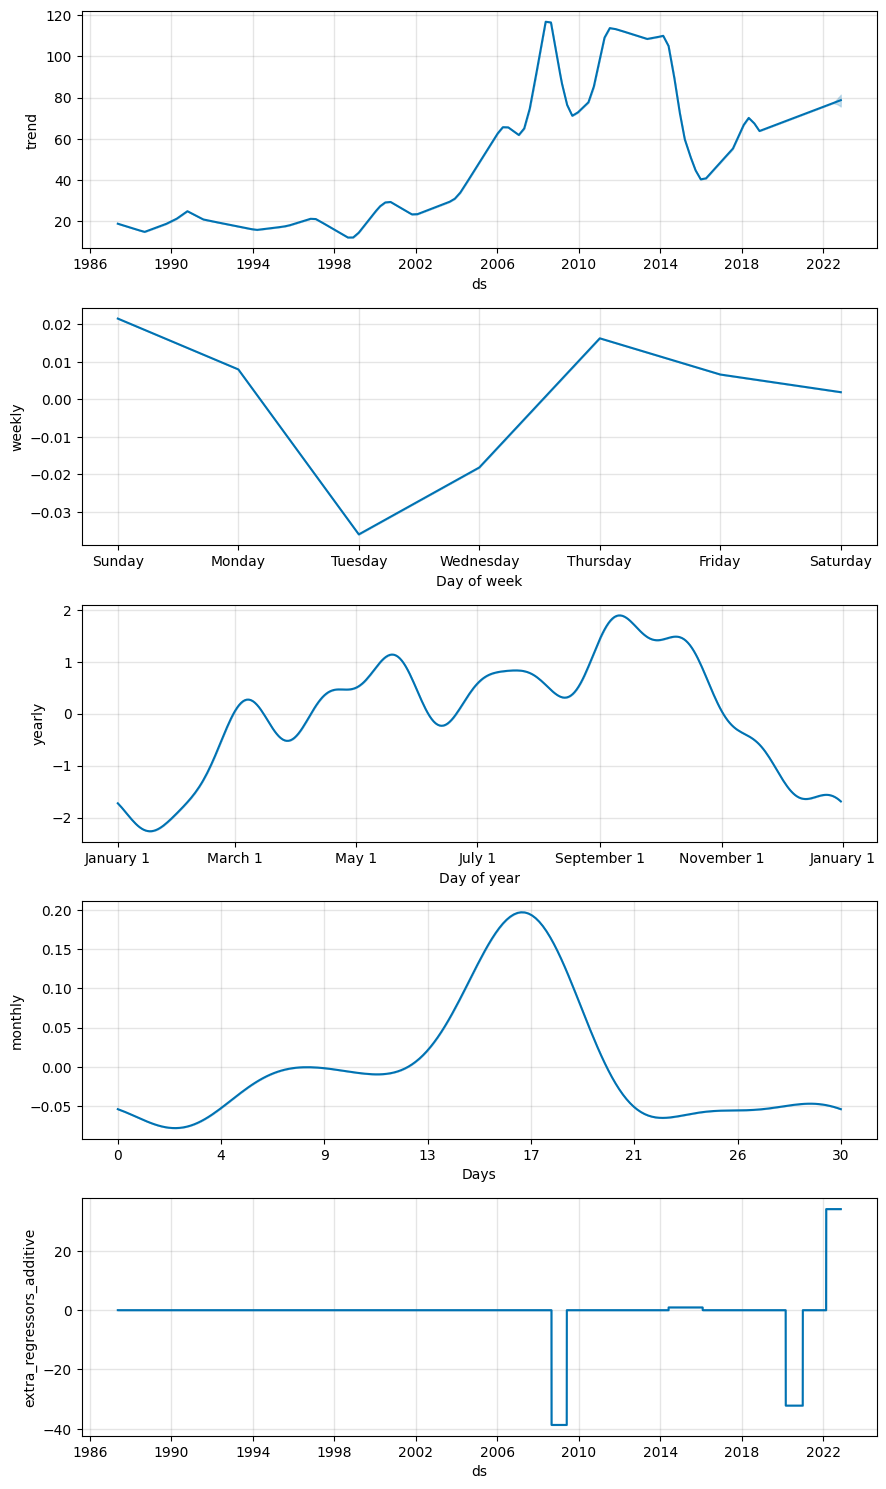

In [58]:
model_prophet.plot_components(forecast_prophet)
plt.show()

RMSE: 13.88
MAE : 12.33
MAPE: 12.45%


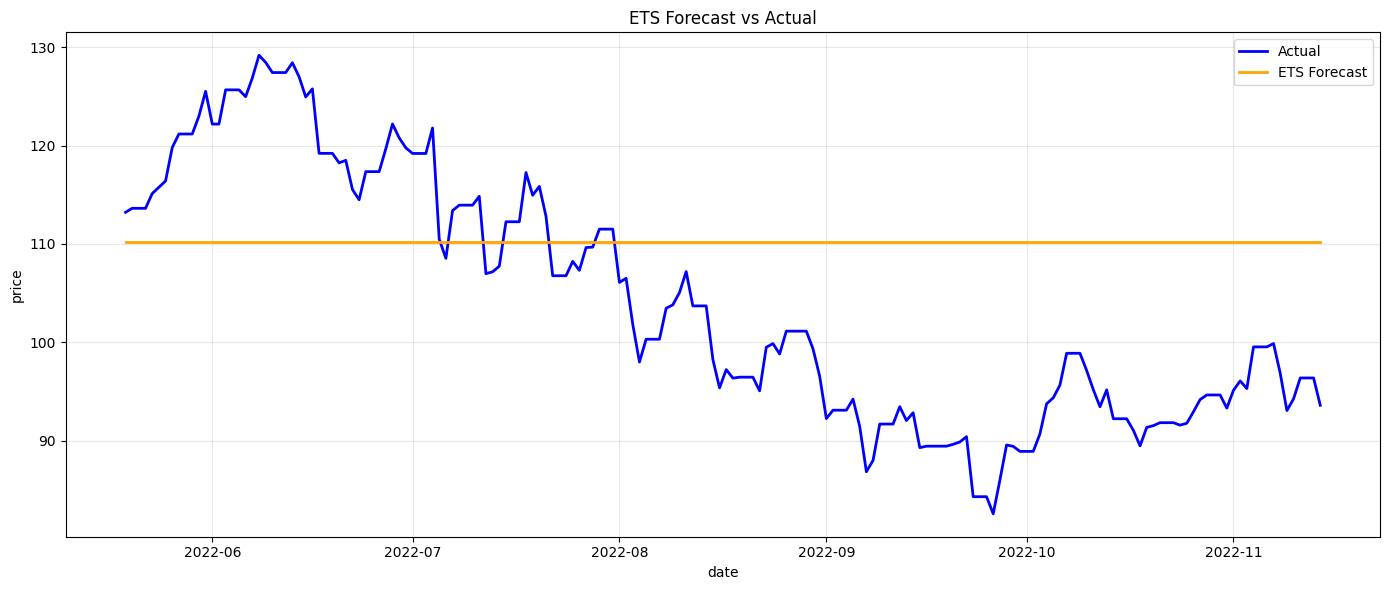

In [59]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Copy of original df
df_copy= df.copy()

# 2. Log Transformation
df_copy['price_log_ets'] = np.log(df_copy['price'])

# 3. Train-Test Split
train_ets = df_copy.iloc[:-180]['price_log_ets']
test_ets = df_copy.iloc[-180:]['price']

# 4. Advanced ETS Model
model_ets = ExponentialSmoothing(
    train_ets,

    # Trend
    trend='add',
    damped_trend=True,

    # Weak seasonality removed
    seasonal=None,

    # Better initialization
    initialization_method='estimated',

    # Variance stabilization
    use_boxcox=True
)

# 5. Fit Model
fit_ets = model_ets.fit(
    optimized=True,
    remove_bias=True
)

# 6. Forecast on Test Set
forecast_test_log_ets = fit_ets.forecast(steps=len(test_ets))

# Convert back from log scale
forecast_test_ets = np.exp(forecast_test_log_ets)

# 7. Evaluation Metrics
rmse = np.sqrt(mean_squared_error(test_ets, forecast_test_ets))
mae = mean_absolute_error(test_ets, forecast_test_ets)

mape = np.mean(np.abs((test_ets - forecast_test_ets) / test_ets)) * 100

print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"MAPE: {mape:.2f}%")

# 8. Train Final Model on Full Data
final_model_ets = ExponentialSmoothing(
    df_copy['price_log_ets'],

    trend='mul',
    damped_trend=True,
    seasonal=None,

    initialization_method='estimated',

    use_boxcox=True
)

final_fit_ets = final_model_ets.fit(
    optimized=True,
    remove_bias=True
)

# 9. Forecast Future Values
future_steps = 180

forecast_future_log_ets = final_fit_ets.forecast(steps=future_steps)

# Convert back from log scale
forecast_future_ets = np.exp(forecast_future_log_ets)

# 10. Create Future Dates
future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=future_steps,
    freq='D'
)

forecast_future_ets.index = future_dates

# 11. Plot Test Forecast
plt.figure(figsize=(14,6))

plt.plot(test_ets.index, test_ets,
         label='Actual',
         color='blue',
         linewidth=2)

plt.plot(test_ets.index, forecast_test_ets,
         label='ETS Forecast',
         color='orange',
         linewidth=2)

plt.title('ETS Forecast vs Actual')
plt.xlabel('date')
plt.ylabel('price')

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [60]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Target Variable
y_ets_cv = df['price']

# Time Series Cross Validation
tscv_ets = TimeSeriesSplit(
    n_splits=5,
    test_size=180
)

# Store Metrics
rmse_scores_ets = []
mae_scores_ets = []
mape_scores_ets = []

# Cross Validation Loop
fold_ets = 1

for train_index_ets, test_index_ets in tscv_ets.split(y_ets_cv):

    # Train-Test Split
    train_ets = y_ets_cv.iloc[train_index_ets]
    test_ets = y_ets_cv.iloc[test_index_ets]

    # ETS Model
    model_ets_cv = ExponentialSmoothing(
        train_ets,

        # Trend
        trend='add',

        # Damped Trend
        damped_trend=True,

        # Seasonality
        seasonal= None,

        # Better initialization
        initialization_method='estimated',

        # Box-cox Transformation
        use_boxcox=True
    )

    # Fit Model
    fit_ets_cv = model_ets_cv.fit(
        optimized=True, # Optimization
        remove_bias=True, # Bias Adjustment

        # Smoothing Parameters
        smoothing_level= 0.03,
        smoothing_trend= 0.03,
    )

    # Forecast
    forecast_ets_cv = fit_ets_cv.forecast(steps=len(test_ets))

    # Evaluation Metrics
    # RMSE
    rmse_ets_cv = np.sqrt(mean_squared_error(test_ets, forecast_ets_cv))

    # MAE
    mae_ets_cv = mean_absolute_error(test_ets, forecast_ets_cv)

    # MAPE
    mape_ets_cv = np.mean(np.abs((test_ets - forecast_ets_cv) / test_ets)) * 100

    # Store Metrics
    rmse_scores_ets.append(rmse_ets_cv)
    mae_scores_ets.append(mae_ets_cv)
    mape_scores_ets.append(mape_ets_cv)

    # Print Fold Results
    print(f"\nFold {fold_ets}")
    print(f"RMSE: {rmse_ets_cv:.2f}")
    print(f"MAE : {mae_ets_cv:.2f}")
    print(f"MAPE: {mape_ets_cv:.2f}%")

    fold_ets += 1

# Average Cross Validation Results
print("\nAverage Cross-Validation Results")
print(f"Average RMSE: "f"{np.mean(rmse_scores_ets):.2f}")
print(f"Average MAE : "f"{np.mean(mae_scores_ets):.2f}")
print(f"Average MAPE: "f"{np.mean(mape_scores_ets):.2f}%")


Fold 1
RMSE: 16.99
MAE : 16.83
MAPE: 40.20%

Fold 2
RMSE: 20.27
MAE : 19.01
MAPE: 30.62%

Fold 3
RMSE: 9.31
MAE : 7.93
MAPE: 10.07%

Fold 4
RMSE: 19.63
MAE : 16.45
MAPE: 16.03%

Fold 5
RMSE: 13.85
MAE : 12.30
MAPE: 12.42%

Average Cross-Validation Results
Average RMSE: 16.01
Average MAE : 14.51
Average MAPE: 21.87%


In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Actual test values
y_true = test['price'].values
# Prophet predictions
y_pred_prophet = forecast_prophet.iloc[-180:]['yhat'].values

# ETS Predictions
y_pred_ets = forecast_test_ets.values

# Evaluation function
def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"{model_name} - RMSE: {rmse:.2f}, MAE: {mae:.2f}, MAPE: {mape:.2f}%")

# Run evaluations
evaluate(y_true, forecast_arima.values, "ARIMA")
evaluate(y_true, forecast_sarima.values, "SARIMAX")
evaluate(y_true, y_pred_prophet, "Prophet")
evaluate(y_true, y_pred_ets, "ETS")

ARIMA - RMSE: 14.39, MAE: 12.76, MAPE: 12.91%
SARIMAX - RMSE: 14.43, MAE: 12.78, MAPE: 12.94%
Prophet - RMSE: 15.80, MAE: 13.73, MAPE: 14.04%
ETS - RMSE: 13.88, MAE: 12.33, MAPE: 12.45%


In [62]:
# Create Cross-Validation Results Table
cv_results = pd.DataFrame({

    'Model': [
        'ARIMA',
        'SARIMA',
        'Prophet',
        'ETS'
    ],

    'Average RMSE': [
        np.mean(rmse_scores_arima),
        np.mean(rmse_scores_sarima),
        np.mean(rmse_scores_prophet),
        np.mean(rmse_scores_ets)
    ],

    'Average MAE': [
        np.mean(mae_scores_arima),
        np.mean(mae_scores_sarima),
        np.mean(mae_scores_prophet),
        np.mean(mae_scores_ets)
    ],

    'Average MAPE (%)': [
        np.mean(mape_scores_arima),
        np.mean(mape_scores_sarima),
        np.mean(mape_scores_prophet),
        np.mean(mape_scores_ets)
    ]
})

# Round Results
cv_results = cv_results.round(2)

# Display Results
print("\nCross-Validation Comparison Results\n")
print(cv_results)


Cross-Validation Comparison Results

     Model  Average RMSE  Average MAE  Average MAPE (%)
0    ARIMA         22.84        17.69             37.08
1   SARIMA         26.96        20.78             42.15
2  Prophet         15.24        13.23             18.26
3      ETS         16.01        14.51             21.87


In [63]:
import joblib

# Save Prophet Model
joblib.dump(model_prophet, 'prophet_model.pkl')

print("Prophet model saved successfully!")

Prophet model saved successfully!


The Prophet model was selected as the final forecasting model because it provided the most stable and reliable performance compared to the ARIMA, SARIMA, and ETS models. It handled long-term trends, sudden shocks, and structural changes effectively by using external regressors and automatic changepoint detection.

Time-based cross-validation was performed using TimeSeriesSplit to evaluate the robustness of each forecasting model on unseen future data. Even though Prophet achieved slightly higher RMSE, MAE, and MAPE scores in model evaluation, the differences between Prophet metrics and the other models metrics were only small,
while Prophet showed better visual forecasting performance and the strongest cross-validation results overall.  
The Prophet model achieved approximately: RMSE: 15.80 MAE: 13.73 MAPE: 14.04%  
Cross-Validation: Average RMSE: 15.24 Average MAE: 13.23 Average MAPE: 18.26%

These results showed that Prophet generalized better across multiple folds and produced more stable forecasts than the other models. Therefore, Prophet was selected as the final model due to its stronger forecasting stability, adaptability to external events, and better cross-validation performance.